In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings 
warnings.filterwarnings('ignore')

In [10]:
tips = pd.read_csv("tips.csv")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


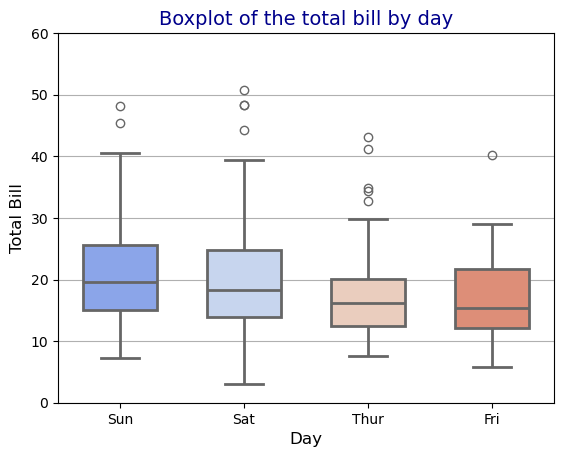

In [19]:
sns.boxplot(x = 'day',
            y = 'total_bill',
            data = tips,
            palette = 'coolwarm',# color map
            width = 0.6,#box width
            linewidth = 2,#line thickness
            fliersize = 6, # Size of outliers marks
           )
plt.ylim(0,60)
plt.title("Boxplot of the total bill by day", fontsize = 14,color = 'darkblue')
plt.xlabel("Day" , fontsize = 12)
plt.ylabel("Total Bill", fontsize = 12)
plt.grid(True,axis  = 'y')
plt.show()

In [28]:
# Five Number summary & Outliers
Q1 = tips["total_bill"].quantile(0.25) # MEdian of first half
Q2 = tips["total_bill"].median() # Median of complete data
Q3 = tips["total_bill"].quantile(0.75) # Median of second half data
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5*IQR
upper_whisker = Q3 + 1.5*IQR

minimum = tips["total_bill"].min()
maximum = tips["total_bill"].max()

outliers = tips[(tips['total_bill'] < lower_whisker) | (tips["total_bill"] > upper_whisker)]["total_bill"]
print(outliers)

print("Box Plot Summary for total_bill")
print(f"Q1 (25th percentile): {Q1:.2f}") # .2f -----> formats number to 2 decimals
print(f"Median Q2(50th percentile): {Q2:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"Lower Whisker: {lower_whisker:.2f}")
print(f"Upper Whisker : {upper_whisker:.2f}")
print(f"Minimum Value : {minimum:.2f}")
print(f"Maximum Value : {maximum:.2f}")
print(f"Outliers: {list(outliers)}")


59     48.27
102    44.30
142    41.19
156    48.17
170    50.81
182    45.35
184    40.55
197    43.11
212    48.33
Name: total_bill, dtype: float64
Box Plot Summary for total_bill
Q1 (25th percentile): 13.35
Median Q2(50th percentile): 17.80
Q3 (75th percentile): 24.13
Lower Whisker: -2.82
Upper Whisker : 40.30
Minimum Value : 3.07
Maximum Value : 50.81
Outliers: [48.27, 44.3, 41.19, 48.17, 50.81, 45.35, 40.55, 43.11, 48.33]


## Voilin plot()

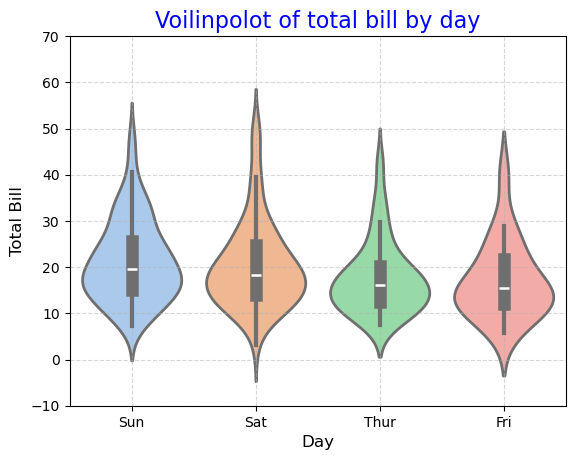

In [34]:
sns.violinplot(
    x = 'day',
    y = 'total_bill',
    palette = 'pastel',
    inner = 'box',
    linewidth = 2,
    data = tips,
    scale = 'width'
    )

plt.ylim(-10,70)
plt.xlabel("Day",fontsize = 12)
plt.ylabel("Total Bill",fontsize = 12)
plt.title("Voilinpolot of total bill by day" , fontsize = 16,color = 'blue')
plt.grid(True , linestyle = '--' , alpha = 0.5)
plt.show()

## Scatter plot

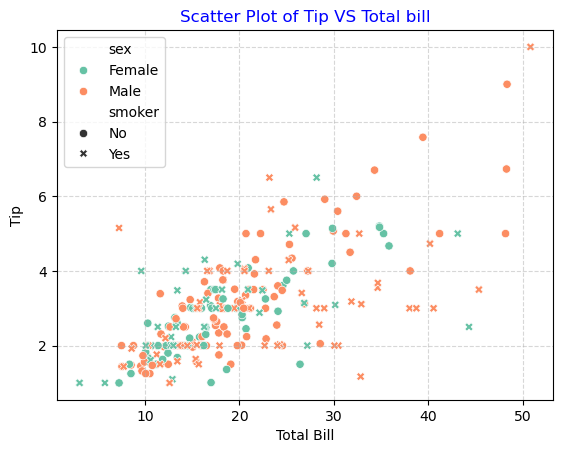

In [37]:
sns.scatterplot(
    x = 'total_bill',
    y = 'tip',
    data = tips,
    style = 'smoker',
    palette = 'Set2',
    hue = 'sex'# color by category(M / F)
)

plt.title("Scatter Plot of Tip VS Total bill",color = 'blue')
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.grid(True , linestyle = '--' , alpha = 0.5)
plt.show()

## Line plot

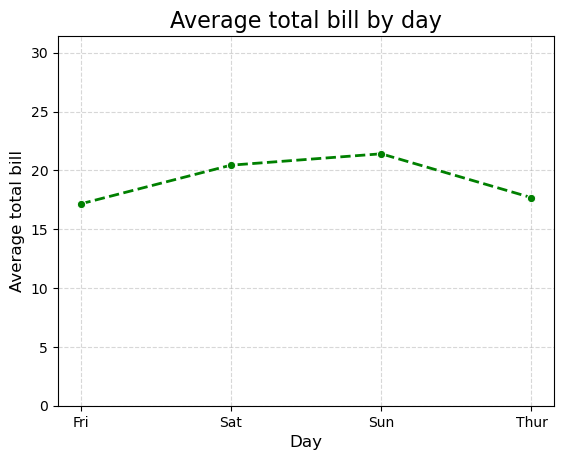

In [40]:
avg_total_bill = tips.groupby('day')['total_bill'].mean().reset_index()
#avg_total_bill

sns.lineplot(
    x = 'day',
    y = 'total_bill',
    data = avg_total_bill ,
    marker = 'o',
    linestyle = '--',
    color = 'g',
    linewidth = 2
)
plt.ylim(0,avg_total_bill['total_bill'].max() + 10)
plt.title("Average total bill by day",fontsize = 16)
plt.xlabel("Day",fontsize = 12)
plt.ylabel("Average total bill" , fontsize = 12)
plt.grid(True,linestyle = '--', alpha = 0.5)

    

# Bar Plot

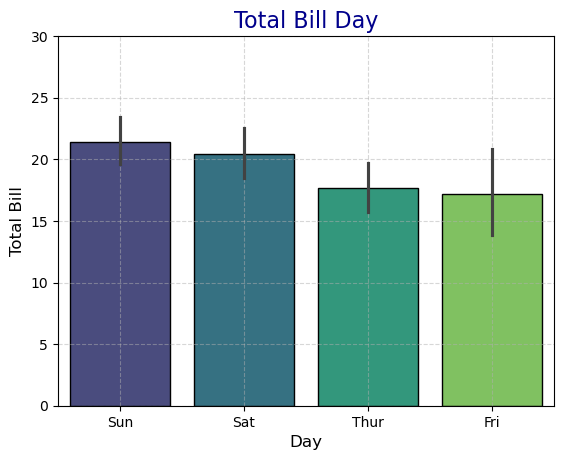

In [43]:
sns.barplot(
    x = 'day',
    y = 'total_bill',
    data = tips,
    palette = 'viridis',
    edgecolor = 'black'
)
plt.ylim(0,30)

plt.title("Total Bill Day",fontsize = 16,color = 'darkblue')
plt.xlabel("Day" ,fontsize = 12)
plt.ylabel("Total Bill",fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

## Pair Plot

Text(0.5, 1.02, 'Pair PLot of total bill , Tip and Size')

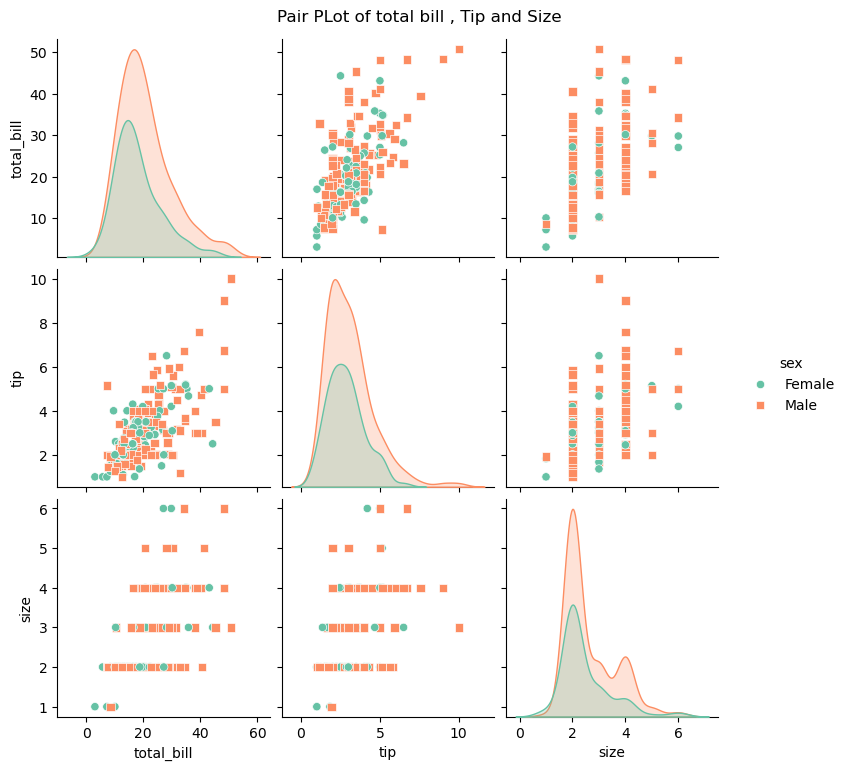

In [47]:
sns.pairplot(
    data = tips,
    vars = ['total_bill','tip','size'],
    hue = 'sex',
    palette = "Set2",
    diag_kind = 'kde',
    markers = ['o','s']
)

plt.suptitle("Pair PLot of total bill , Tip and Size",y = 1.02)
#suptitle --- > super title , means a title for 

## Heat Map

In [49]:
numeric_data = tips.select_dtypes(include = ['number'])

corr = numeric_data.corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000
